In [12]:
import matplotlib.font_manager as fm
from matplotlib import rcParams

font_path = '/home/shariat/Documents/fonts/Helvetica.ttf'
fm.fontManager.addfont(font_path)           # add it globally
rcParams['font.family'] = 'Helvetica'  # set default

In [13]:
import numpy as np
import pandas as pd
import joblib
import os
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [14]:
# ========================= CONFIG =========================
MODEL_DIR = "/home/shariat/Astronomy/TTV/Validation/Models"
DATA_PATH = "/home/shariat/Astronomy/TTV/Validation/Data/PS_2026.06.08_12.38.35_new.csv"

MODEL_NAME = "tess_adaboost_model.pkl"
SCALER_NAME = "tess_adaboost_scaler.pkl"

THRESHOLD = 0.5

features = [
    'pl_orbper', 'pl_orbsmax', 'pl_rade', 'pl_masse', 'pl_orbeccen',
    'pl_insol', 'pl_eqt', 'pl_orbincl', 'pl_trandep', 'pl_trandur',
    'pl_ratdor', 'pl_ratror', 'st_teff', 'st_rad', 'st_mass'
]

target = 'ttv_flag'

In [15]:
def load_model_and_scaler():
    model_path = os.path.join(MODEL_DIR, MODEL_NAME)
    scaler_path = os.path.join(MODEL_DIR, SCALER_NAME)
    
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)
    
    print(f"Loaded AdaBoost Model: {MODEL_NAME}")
    print(f"Loaded Scaler: {SCALER_NAME}")
    print(f"Prediction Threshold: {THRESHOLD}")
    return model, scaler

In [16]:
def preprocess_data():
    print("Loading and preprocessing TESS data...")
    data = pd.read_csv(DATA_PATH, comment='#')
    
    data['disc_pubdate'] = pd.to_datetime(data['disc_pubdate'], format='%Y-%m', errors='coerce')
    start_date = pd.to_datetime('2025-11')
    end_date = pd.to_datetime('2026-06')
    data = data[(data['disc_pubdate'] >= start_date) & (data['disc_pubdate'] <= end_date)]
    
    tess_data = data[data['disc_facility'].isin(['Transiting Exoplanet Survey Satellite (TESS)'])].copy()
    tess_data = tess_data.dropna(subset=[target])
    
    print(f"Total TESS samples: {len(tess_data)}")
    print("Actual TTV distribution:")
    print(tess_data[target].value_counts())
    
    # Median imputation (same as training)
    for col in features:
        if col in tess_data.columns:
            median_val = tess_data[col].median()
            tess_data[col] = tess_data[col].fillna(0 if pd.isna(median_val) else median_val)
    
    tess_data = tess_data.dropna(subset=features)
    
    X = tess_data[features].values
    y_true = tess_data[target].values.astype(int)
    
    return tess_data, X, y_true

Loaded AdaBoost Model: tess_adaboost_model.pkl
Loaded Scaler: tess_adaboost_scaler.pkl
Prediction Threshold: 0.5
Loading and preprocessing TESS data...
Total TESS samples: 339
Actual TTV distribution:
ttv_flag
0    318
1     21
Name: count, dtype: int64

TESS ADABOOST PREDICTIONS (Threshold = 0.5)
        pl_name disc_pubdate                                disc_facility  ttv_flag  ttv_predicted  ttv_probability  confidence
     TOI-4507 b   2026-01-01 Transiting Exoplanet Survey Satellite (TESS)         0              1           0.7796      0.7796
     TOI-5614 b   2026-03-01 Transiting Exoplanet Survey Satellite (TESS)         0              1           0.6866      0.6866
TIC 154870955 b   2026-03-01 Transiting Exoplanet Survey Satellite (TESS)         0              1           0.6800      0.6800
      NGTS-35 b   2026-04-01 Transiting Exoplanet Survey Satellite (TESS)         0              1           0.6740      0.6740
     TOI-4507 b   2026-01-01 Transiting Exoplanet Survey Sate

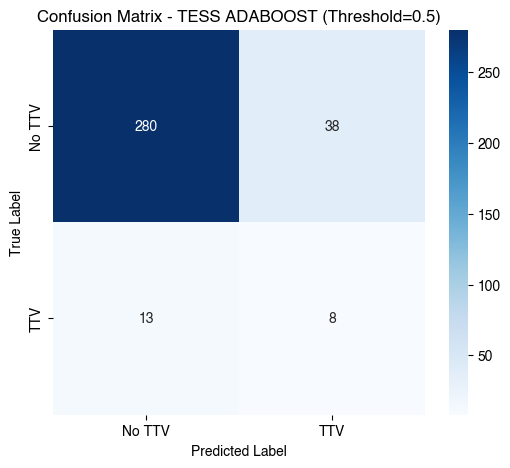


 Predictions saved to: /home/shariat/Astronomy/TTV/Validation/predictions_tess_adaboost_th0.5.csv


In [17]:
if __name__ == "__main__":
    model, scaler = load_model_and_scaler()
    df, X_raw, y_true = preprocess_data()
    
    X_scaled = scaler.transform(X_raw)
    
    y_proba = model.predict_proba(X_scaled)[:, 1]
    y_pred = (y_proba >= THRESHOLD).astype(int)
    
    # Results
    results = df.copy()
    results['ttv_predicted'] = y_pred
    results['ttv_probability'] = y_proba.round(4)
    results['confidence'] = np.where(y_pred == 1, y_proba, 1 - y_proba).round(4)
    
    print("\n" + "="*80)
    print(f"TESS ADABOOST PREDICTIONS (Threshold = {THRESHOLD})")
    print("="*80)
    
    display_cols = ['pl_name', 'disc_pubdate', 'disc_facility', target, 
                   'ttv_predicted', 'ttv_probability', 'confidence']
    
    print(results[display_cols].sort_values(by='ttv_probability', ascending=False).to_string(index=False))
    
    # Evaluation with safe handling
    if len(y_true) > 0:
        print(f"\nAccuracy: {accuracy_score(y_true, y_pred):.4f}")
        
        # Safe Classification Report
        unique_classes = np.unique(np.concatenate([y_true, y_pred]))
        if len(unique_classes) == 1:
            print("\n Only one class present in data/predictions. Classification Report skipped.")
            print("True labels :", np.unique(y_true))
            print("Predicted labels:", np.unique(y_pred))
        else:
            print("\n📊 Classification Report:")
            print(classification_report(y_true, y_pred, 
                                      target_names=['No TTV', 'TTV'], 
                                      zero_division=0))
        
        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['No TTV', 'TTV'], 
                    yticklabels=['No TTV', 'TTV'])
        plt.title(f'Confusion Matrix - TESS ADABOOST (Threshold={THRESHOLD})')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()
    
    # Save predictions
    output_path = f"/home/shariat/Astronomy/TTV/Validation/predictions_tess_adaboost_th{THRESHOLD}.csv"
    results.to_csv(output_path, index=False)
    print(f"\n Predictions saved to: {output_path}")